In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import ViTForImageClassification, ViTImageProcessor, ViTConfig # pytorch based model
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import kagglehub

import os


f:\MyCondaEnvs\ML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

path="C:\\Users\\eric huang\\.cache\\kagglehub\\datasets\\piaoya\\plastic-recycling-codes\\versions\\9\\seven_plastics"

In [3]:
from PlasticPredictorModel import *


In [4]:
model = PlasticPredictorModel()
val_dataset = model.train()
print(val_dataset)  # Should NOT be None


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10 - Train Loss: 1.9336, Val Loss: 1.7389, Val Acc: 0.3650
Epoch 2/10 - Train Loss: 1.5739, Val Loss: 1.5048, Val Acc: 0.4453
Epoch 3/10 - Train Loss: 1.2724, Val Loss: 1.3397, Val Acc: 0.5912
Epoch 4/10 - Train Loss: 0.9676, Val Loss: 1.1561, Val Acc: 0.6423
Epoch 5/10 - Train Loss: 0.6724, Val Loss: 1.0181, Val Acc: 0.7153
Epoch 6/10 - Train Loss: 0.4631, Val Loss: 0.9085, Val Acc: 0.7664
Epoch 7/10 - Train Loss: 0.3292, Val Loss: 0.8152, Val Acc: 0.7591
Epoch 8/10 - Train Loss: 0.2449, Val Loss: 0.7690, Val Acc: 0.7737
Epoch 9/10 - Train Loss: 0.1871, Val Loss: 0.7896, Val Acc: 0.7518
Epoch 10/10 - Train Loss: 0.1494, Val Loss: 0.7422, Val Acc: 0.7737
Model saved to plastic_predictor.pth


In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, dataset, classes, batch_size=64, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    model.eval()

    test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images).logits
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=classes)

    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print("\nClassification Report:\n", report)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Test Accuracy: 77.37%

Classification Report:
                                    precision    recall  f1-score   support

               1_polyethylene_PET       0.71      0.74      0.72        23
2_high_density_polyethylene_PE-HD       1.00      0.50      0.67        20
          3_polyvinylchloride_PVC       1.00      0.50      0.67         2
 4_low_density_polyethylene_PE-LD       0.69      0.91      0.78        22
               5_polypropylene_PP       0.73      0.90      0.80        41
                 6_polystyrene_PS       0.50      0.25      0.33         4
                   7_other_resins       1.00      0.67      0.80         6
                     8_no_plastic       1.00      0.84      0.91        19

                         accuracy                           0.77       137
                        macro avg       0.83      0.66      0.71       137
                     weighted avg       0.80      0.77      0.77       137



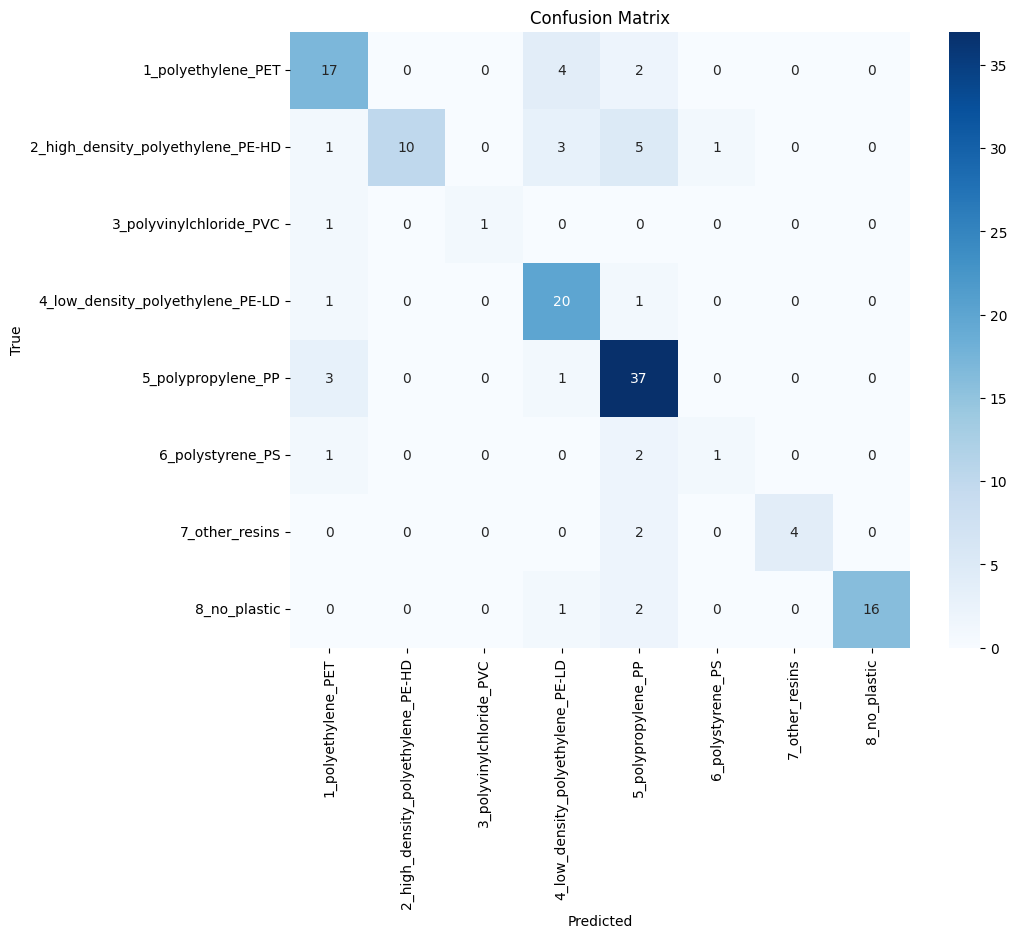

In [10]:
evaluate_model(
    model=model.model,   # model.model because you saved ViT inside
    dataset=val_dataset,
    classes=model.classes,
    batch_size=64
)

In [11]:
import os
print("Subfolders:", os.listdir(path))


Subfolders: ['1_polyethylene_PET', '2_high_density_polyethylene_PE-HD', '3_polyvinylchloride_PVC', '4_low_density_polyethylene_PE-LD', '5_polypropylene_PP', '6_polystyrene_PS', '7_other_resins', '8_no_plastic']


In [ ]:
# Currently we have to retrain the entire model to get val_dataset. 

In [12]:
from torch.utils.data import Subset